In [47]:
import pandas as pd
df_changes = pd.read_csv("country_changes.csv")
print(df_changes)

    country_code  death_2000  death_2019  death_change      gdp_2000  \
0            ALB       5.619       7.473         1.854   1160.420471   
1            DZA       5.109       4.681        -0.428   1772.928691   
2            AND       6.228       5.560        -0.668  21810.250380   
3            AGO      18.080       7.701       -10.379    563.733796   
4            ATG       6.254       6.448         0.194  12027.494980   
..           ...         ...         ...           ...           ...   
177          UZB       7.006       5.970        -1.036    555.149231   
178          VUT       5.334       5.494         0.160   1460.238177   
179          VNM       5.486       6.300         0.814    404.029784   
180          PSE       4.500       3.134        -1.366   1476.171850   
181          ZMB      16.198       6.482        -9.716    359.429501   

         gdp_2019    gdp_change  health_2000  health_2019  health_change  \
0     6069.439031   4909.018560    65.476746   366.340149  

In [48]:
#Create log changes

import numpy as np

# GDP
df_changes["log_gdp_change"] = np.log(df_changes["gdp_2019"]) - np.log(df_changes["gdp_2000"])

# Health
df_changes["log_health_change"] = np.log(df_changes["health_2019"]) - np.log(df_changes["health_2000"])

In [49]:
#Creates correlation matrix to see correlation between predictor variables and dependent variable (change in mortality rate)
corr_matrix = df_changes[[
    "death_change",
    "log_gdp_change",
    "log_health_change",
    "pop_65_change"
]].corr()

print(corr_matrix)

                   death_change  log_gdp_change  log_health_change  \
death_change           1.000000       -0.077542          -0.006860   
log_gdp_change        -0.077542        1.000000           0.781329   
log_health_change     -0.006860        0.781329           1.000000   
pop_65_change          0.614353        0.008515           0.107532   

                   pop_65_change  
death_change            0.614353  
log_gdp_change          0.008515  
log_health_change       0.107532  
pop_65_change           1.000000  


In [50]:
#The purpose of this is to count how many rows there are with values that are <= 0
#Because having rows with values less than or equal to 0 doesn't make sense if we take logs of variables
#gdp and health per capita values cannot be <= 0
print((df_changes["gdp_2000"] <= 0).sum())
print((df_changes["gdp_2019"] <= 0).sum())

print((df_changes["health_2000"] <= 0).sum())
print((df_changes["health_2019"] <= 0).sum())

0
0
0
0


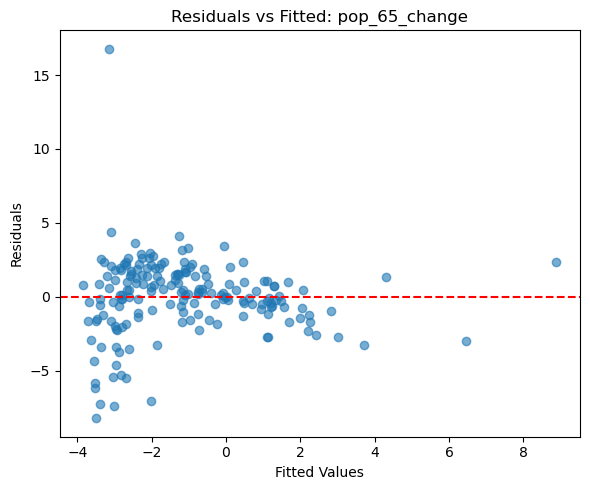

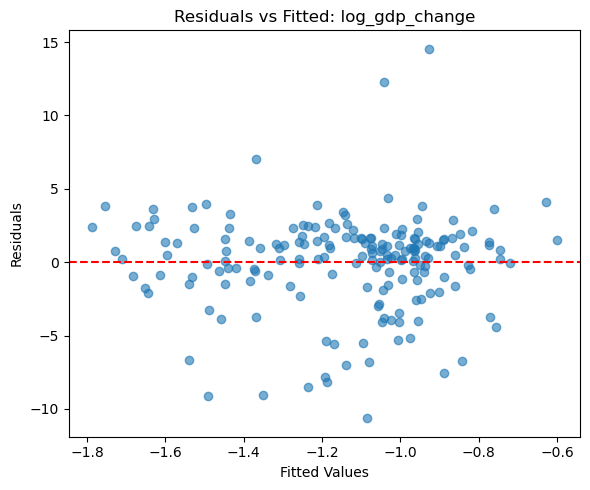

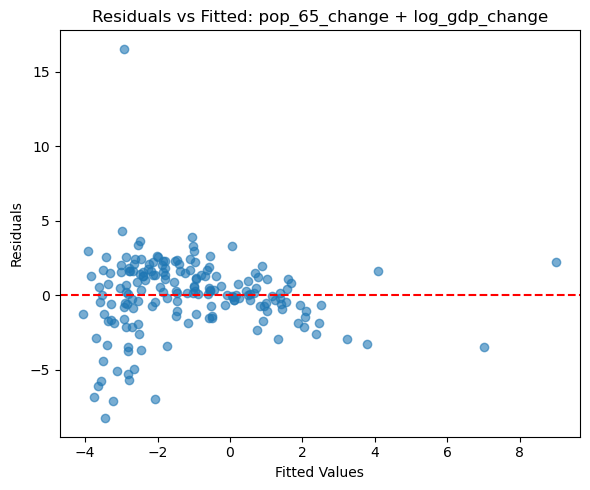

In [58]:
#Creating residual plots for the linear regression models (simple linear and multivariate)
import matplotlib.pyplot as plt
import numpy as np

def plot_residuals_vs_fitted(model, model_name):
    fitted = model.fittedvalues
    residuals = model.resid

    plt.figure(figsize=(6, 5))
    plt.scatter(fitted, residuals, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Fitted Values")
    plt.ylabel("Residuals")
    plt.title(f"Residuals vs Fitted: {model_name}")
    plt.tight_layout()
    plt.show()


# Simple regression: pop_65_change
X1 = sm.add_constant(df_changes["pop_65_change"])
model1 = sm.OLS(df_changes["death_change"], X1).fit()
plot_residuals_vs_fitted(model1, "pop_65_change")

# Simple regression: log_gdp_change
X2 = sm.add_constant(df_changes["log_gdp_change"])
model2 = sm.OLS(df_changes["death_change"], X2).fit()
plot_residuals_vs_fitted(model2, "log_gdp_change")

# Multivariate: pop_65_change + log_gdp_change
X3 = sm.add_constant(df_changes[["pop_65_change", "log_gdp_change"]])
model3 = sm.OLS(df_changes["death_change"], X3).fit()
plot_residuals_vs_fitted(model3, "pop_65_change + log_gdp_change")

In [52]:
#Regression 1: simple linear regression of log_gdp_change vs. death_change

import statsmodels.api as sm

X = df_changes["log_gdp_change"]
y = df_changes["death_change"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           death_change   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.089
Date:                Mon, 27 Apr 2026   Prob (F-statistic):              0.298
Time:                        20:44:53   Log-Likelihood:                -472.51
No. Observations:                 182   AIC:                             949.0
Df Residuals:                     180   BIC:                             955.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.6135      0.562     -1.

In [53]:
#Regression 2: Polynomial, log_gdp_change_squared vs. death_change - uses squared term
df_changes["log_gdp_change_sq"] = df_changes["log_gdp_change"] ** 2

# Polynomial regression: log_gdp_change + log_gdp_change²
X_poly = sm.add_constant(df_changes[["log_gdp_change", "log_gdp_change_sq"]])
model_poly_gdp = sm.OLS(df_changes["death_change"], X_poly).fit()
print(model_poly_gdp.summary())

                            OLS Regression Results                            
Dep. Variable:           death_change   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     1.757
Date:                Mon, 27 Apr 2026   Prob (F-statistic):              0.175
Time:                        20:44:53   Log-Likelihood:                -471.29
No. Observations:                 182   AIC:                             948.6
Df Residuals:                     179   BIC:                             958.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.8861      1.11

In [54]:
#Regression 3: Simple linear regression for pop_65_change vs. death_change
import statsmodels.api as sm

X = df_changes["pop_65_change"]
y = df_changes["death_change"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           death_change   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.374
Method:                 Least Squares   F-statistic:                     109.1
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           2.87e-20
Time:                        20:44:53   Log-Likelihood:                -429.94
No. Observations:                 182   AIC:                             863.9
Df Residuals:                     180   BIC:                             870.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -3.0461      0.264    -11.525

In [55]:
#Regression 4: Polynomial, pop_65_change_squared vs. death_change
# Create squared term
df_changes["pop_65_change_sq"] = df_changes["pop_65_change"] ** 2

# Polynomial regression: pop_65_change + pop_65_change²
X_poly_pop = sm.add_constant(df_changes[["pop_65_change", "pop_65_change_sq"]])
model_poly_pop = sm.OLS(df_changes["death_change"], X_poly_pop).fit()
print(model_poly_pop.summary())

                            OLS Regression Results                            
Dep. Variable:           death_change   R-squared:                       0.384
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     55.87
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           1.40e-19
Time:                        20:44:53   Log-Likelihood:                -428.93
No. Observations:                 182   AIC:                             863.9
Df Residuals:                     179   BIC:                             873.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -3.2240      0.292  

In [56]:
#Regression 5: logarithmic regression for pop_65_change vs. death_change
# Create log term for pop_65_change
# Need to handle the negative/zero values first since you can't take log of those
df_changes["log_pop_65_change"] = np.log(df_changes["pop_65_change"].clip(lower=0.001))

# Logarithmic regression
X_log_pop = sm.add_constant(df_changes["log_pop_65_change"])
model_log_pop = sm.OLS(df_changes["death_change"], X_log_pop).fit()
print(model_log_pop.summary())

                            OLS Regression Results                            
Dep. Variable:           death_change   R-squared:                       0.302
Model:                            OLS   Adj. R-squared:                  0.298
Method:                 Least Squares   F-statistic:                     77.78
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           9.80e-16
Time:                        20:44:53   Log-Likelihood:                -440.38
No. Observations:                 182   AIC:                             884.8
Df Residuals:                     180   BIC:                             891.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.7907      0.20

In [57]:
#Regression 6: Multivariate linear regression with pop_65_change + log_gdp_change vs. death_change

import statsmodels.api as sm

# Define dependent and independent variables
y = df_changes['death_change']
X = df_changes[['pop_65_change', 'log_gdp_change']]

# Add constant (intercept)
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Print results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           death_change   R-squared:                       0.384
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     55.86
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           1.41e-19
Time:                        20:44:53   Log-Likelihood:                -428.93
No. Observations:                 182   AIC:                             863.9
Df Residuals:                     179   BIC:                             873.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.4833      0.478     -5.